<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=1): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
0.9994871794871795
KNN classifier accuracy (k=2): 99.95%

Predicted     0    1
Actual              
0          1469    1
1             0  480
<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=3): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=4): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
0.9989743589743589
KNN classifier accuracy (k=5): 99.90%

Predicted     0    1
Actual              
0          1468    2
1             0  480
<class 'numpy.float64'>
1.0
KNN classifier accuracy (k=6): 100.00%

Predicted     0    1
Actual              
0          1470    0
1             0  480
<class 'numpy.floa

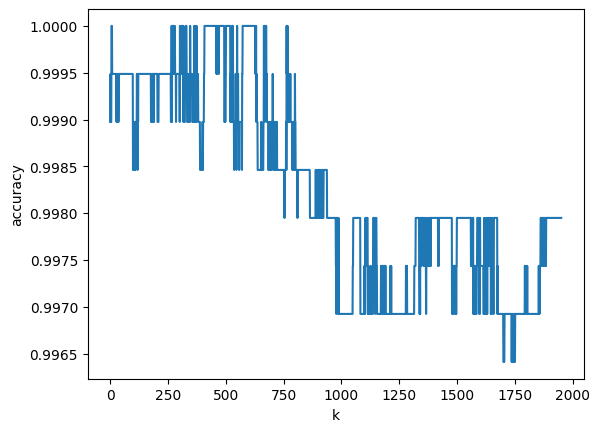

[6, 7, 8, 266, 268, 270, 271, 272, 274, 275, 276, 280, 302, 308, 310, 311, 312, 316, 326, 327, 328, 329, 330, 346, 364, 366, 374, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 461, 463, 464, 465, 466, 467, 468, 469, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 527, 528, 529, 530, 531, 549, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 629, 631, 665, 667, 668, 669, 670, 671, 673, 674, 675, 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
Wine = pd.read_csv("/workspaces/Human-vs-ML-Project/data/Wine.csv")
WineFeatures = pd.read_csv("/workspaces/Human-vs-ML-Project/data/Wine_Feature.csv")

X = WineFeatures
Wine["targetData"] = Wine["color"].apply(lambda color: 1 if color == "red" else 0)
y = Wine["targetData"]
# print(y.head(10))
# print(X.head(10))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

accuracy_list = []
kval = []
best = []

#6,7,8 are the best values for k as they get 100% accuracy
#How does 767 get 100% accuracy??????
#[6, 7, 8, 266, 268, 270, 271, 272, 274, 275, 276, 280, 302, 308, 310, 311, 312, 316, 326, 327, 328, 329, 330, 346, 364, 366, 374, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 461, 463, 464, 465, 466, 467, 468, 469, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 527, 528, 529, 530, 531, 549, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 629, 631, 665, 667, 668, 669, 670, 671, 673, 674, 675, 763, 765, 767]

for i in range(len(y_test)):
    k = i+1
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    y_train_pred = knn.predict(X_train)

    conf_matrix_knn = pd.crosstab(
        y_test,
        y_pred,
        rownames=['Actual'],
        colnames=['Predicted']
    )

    accuracy_knn = (y_pred == y_test).mean()

    accuracy_list.append(accuracy_knn)
    kval.append(k)

    if accuracy_knn == 1:
        best.append(k)

    print(type(accuracy_knn))
    print(accuracy_knn)
    print(f"KNN classifier accuracy (k={k}): {accuracy_knn:.2%}\n")
    print(conf_matrix_knn)

plt.plot(kval, accuracy_list)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.show()

print(best)